# test $M_{\rm surv}$ implementation 

In [1]:
import os
import numpy as np

from sedflow import flows

In [2]:
# --- plotting --- 
import corner as DFM
import matplotlib as mpl
import matplotlib.pyplot as plt
#mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

load test data

In [3]:
i = 999
dat_dir = '/tigress/chhahn/sedflow/seds/modelb/'

sps = np.load(os.path.join(dat_dir, 'train_sed.modelb.%i.thetas_sps.npz' % i))['arr_0']
tage = np.load(os.path.join(dat_dir, 'train_sed.modelb.%i.msurv_t_age.npz.npy' % i))
msurv_nmf = np.load(os.path.join(dat_dir, 'train_sed.modelb.%i.msurv_fsurv_nmf.npz.npy' % i))
msurv_burst = np.load(os.path.join(dat_dir, 'train_sed.modelb.%i.msurv_fsurv_burst.npz.npy' % i))

## compare against emulator

In [4]:
flo = flows.DESIflow()

In [18]:
_msurv = flo._msurv(sps, tage)
_msurv_nmf = flo._msurv_nmf(sps, tage[:,None])
_msurv_burst = flo._msurv_burst(sps, tage[:,None])

In [19]:
msurv_true = (1. - sps[:,5]) * msurv_nmf.flatten() + sps[:,5] * msurv_burst.flatten()

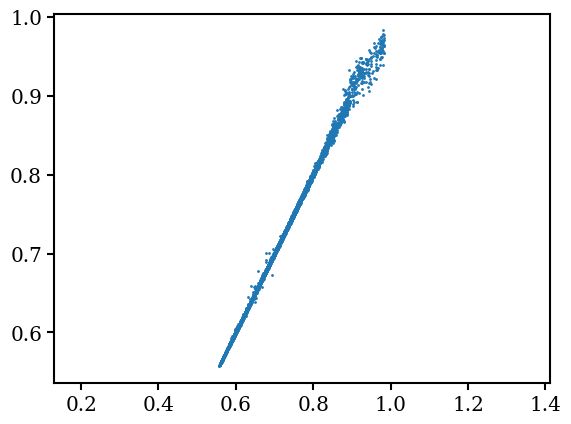

In [20]:
plt.scatter(msurv_nmf, _msurv_nmf, s=1)

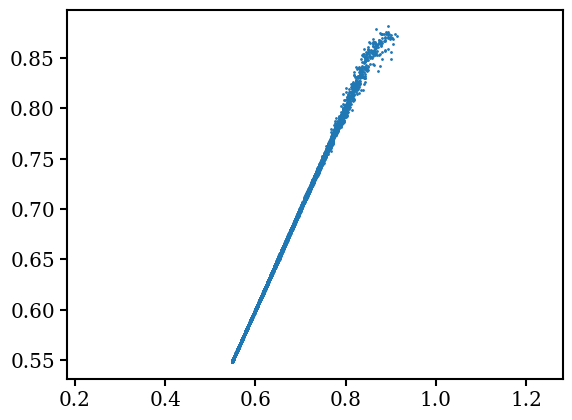

In [21]:
plt.scatter(msurv_burst, _msurv_burst, s=1)

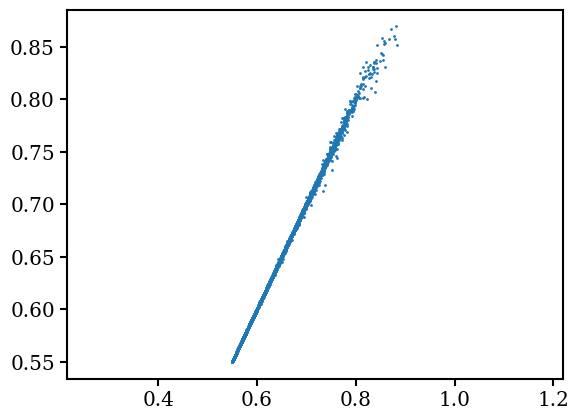

In [17]:
plt.scatter(msurv_true[sps[:,6] < tage], 10**(_msurv-sps[:,0])[sps[:,6] < tage], s=1)